In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, to_date, lower, trim
from pyspark.sql import functions as F
import os
from pyspark.sql import Window

In [2]:
spark = SparkSession.builder \
    .appName("VenchiDataLoading") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/10 19:12:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Read Data

In [3]:
current_path = os.getcwd()
print(current_path)

parent_path = os.path.dirname(current_path)
print(parent_path)

/Users/matteorossi/Desktop/venchi_project/venchi_jMLE_candidate_pack/submission
/Users/matteorossi/Desktop/venchi_project/venchi_jMLE_candidate_pack


In [4]:
# 2. Construct absolute paths using os.path.join 
# This automatically handles slashes correctly for Mac/Linux/Windows
accounts_path = os.path.join(parent_path, 'data', 'accounts.parquet')
interactions_path = os.path.join(parent_path, 'data', 'interactions.parquet')
products_path = os.path.join(parent_path, 'data', 'products.txt')
sales_path = os.path.join(parent_path, 'data', 'sales.parquet')

# 3. Read the data in Spark
# Spark will now receive the full, absolute path (e.g., /Users/Name/Project/data/accounts.parquet)
accounts_df = spark.read.parquet(accounts_path)
accounts_df.printSchema()
interactions_df = spark.read.parquet(interactions_path)
interactions_df.printSchema()
sales_df = spark.read.parquet(sales_path)
sales_df.printSchema()
products_df = spark.read.csv(products_path, sep='\t', header=True, inferSchema=True)
products_df.printSchema()

root
 |-- account_id: string (nullable = true)
 |-- hct: long (nullable = true)
 |-- staff: long (nullable = true)
 |-- turnover_m_usd: long (nullable = true)
 |-- brand_loyalty: long (nullable = true)
 |-- timestamp: string (nullable = true)

root
 |-- interaction_id: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- duration_mins: long (nullable = true)
 |-- response: string (nullable = true)
 |-- topic: string (nullable = true)
 |-- date: string (nullable = true)
 |-- account_id: string (nullable = true)
 |-- product_id: string (nullable = true)

root
 |-- sale_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- account_id: string (nullable = true)
 |-- product_id: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- maturity: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- category: string (nullable = true)
 |-- patent_id: string (nullable = true)



### Data Cleaning

In [5]:
accounts_clean = accounts_df.filter(col("account_id").isNotNull())

interactions_clean = interactions_df.filter(col("account_id").isNotNull()) \
    .withColumn("topic_clean", lower(trim(col("topic")))) \
    .withColumn("channel_clean", lower(trim(col("channel")))) \
    .withColumn("response_clean", lower(trim(col("response"))))

sales_clean = sales_df.filter(col("account_id").isNotNull())
products_clean = products_df.filter(col("product_id").isNotNull())

In [6]:
accounts_clean.filter(col("account_id") == "fd242bcbfb732223d528a501ccfcbc7d").show()

+--------------------+---+-----+--------------+-------------+-------------------+
|          account_id|hct|staff|turnover_m_usd|brand_loyalty|          timestamp|
+--------------------+---+-----+--------------+-------------+-------------------+
|fd242bcbfb732223d...| 83|   13|            83|            7|2020-06-07 11:40:37|
|fd242bcbfb732223d...| 91|   18|            87|           14|2020-04-14 03:22:11|
|fd242bcbfb732223d...| 88|   21|            92|           16|2020-01-31 18:22:15|
+--------------------+---+-----+--------------+-------------+-------------------+



In [7]:
# Order by timestamp DESCENDING (newest first)
latest_window = Window.partitionBy("account_id").orderBy(F.col("timestamp").desc())

# Keep only the newest record per account
deduplicated_accounts = (
    accounts_clean
    .withColumn("row_num", F.row_number().over(latest_window))
    .filter(F.col("row_num") == 1)
    .drop("row_num") # Drop the helper column when done
)

In [8]:
accounts_clean.groupBy("account_id").count().orderBy('count').filter(col("count") > 1).toPandas()

,account_id,count
0,d1022401b7eec8871ae15060675defd8,2
1,0ffe7466d9271fdea80561895e646212,2
2,edba0822938758da14ea7bf2115f33a5,2
3,c8937bf01102a4c633d99c2789776ab2,2
4,fb8a2c3a0a50442354fe11ae6b9f9d21,2
...,...,...
2131,fd242bcbfb732223d528a501ccfcbc7d,3
2132,01459f98eb6004b1acec895aad76ed64,3
2133,04c6f523dbbf07accf50428134daf4d5,3
2134,0368996b1a19e1aa1034363420a95fe5,3


In [9]:
deduplicated_accounts.groupBy("account_id").count().orderBy('count').filter(col("count") > 1).toPandas()

,account_id,count


In [10]:
accounts_clean = deduplicated_accounts

In [11]:
sales_clean.groupBy("sale_id").count().orderBy('count').filter(col("count") > 1).toPandas()

,sale_id,count


In [12]:
interactions_clean.groupBy("interaction_id").count().orderBy('count').filter(col("count") > 1).toPandas()

,interaction_id,count


In [13]:
products_clean.groupBy("product_id").count().orderBy('count').filter(col("count") > 1).toPandas()

,product_id,count


## Task 1

### KPI 1: Total Revenue Generated

In [ ]:
sales_with_price = sales_clean.join(products_clean, on="product_id", how="left")
sales_with_price.printSchema()

root
 |-- product_id: string (nullable = true)
 |-- sale_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- account_id: string (nullable = true)
 |-- maturity: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- category: string (nullable = true)
 |-- patent_id: string (nullable = true)



In [42]:
sales_with_price.show()

+--------------------+--------------------+--------------------+--------------------+-----------+-----+------------+--------------------+
|          product_id|             sale_id|                date|          account_id|   maturity|price|    category|           patent_id|
+--------------------+--------------------+--------------------+--------------------+-----------+-----+------------+--------------------+
|c33fa8699cbf4d3ad...|de4926d6b21ce94a2...|2020-08-05T00:00:...|6ae86cb3cc0545373...|        new|  494|       seeds|96b2fb148ff71d24c...|
|b8b0d30eb31d37099...|d177d2da3228a2aaa...|2019-07-17T00:00:...|e9068679a0ab43825...|        new| 1387|        feed|734f3d3e9c3483553...|
|cbac9ba555e1ea334...|d547b135ebec7e037...|2020-09-26T00:00:...|3975e56c9674956ff...|established| 3160|anti-biotics|7b8dc6ed0170076c8...|
|cbac9ba555e1ea334...|db5de468f444e2efa...|2020-08-31T00:00:...|4dd9d7924bc030f6a...|established| 3160|anti-biotics|7b8dc6ed0170076c8...|
|a35d73f1178e8bdb1...|a74300f8a952

In [15]:
# Aggregate revenue per customer
kpi_revenue = sales_with_price.groupBy("account_id").agg(
    F.sum("price").alias("total_revenue")
)

In [16]:
kpi_revenue.show(10)

+--------------------+-------------+
|          account_id|total_revenue|
+--------------------+-------------+
|e1672d506568deedf...|       121980|
|cb04cb651869ca904...|        56680|
|a054955a13c04e9aa...|       106884|
|115d1256179d8ca02...|        89245|
|ccaf873af5b6fdd3b...|        93540|
|2aca7152120b6433f...|        39077|
|caf1c34f21405ceb6...|        68992|
|79f393197ee0b3251...|        45490|
|0ff82ad074e663021...|        63555|
|21fc105190774346e...|        63909|
+--------------------+-------------+
only showing top 10 rows


In [17]:
## Extra interesting KPI 

kpi_revenue_product = sales_with_price.groupBy("account_id", "product_id").agg(
    F.sum("price").alias("total_revenue")
)


kpi_revenue_category = sales_with_price.groupBy("account_id", "category").agg(
    F.sum("price").alias("total_revenue")
)

### KPI 2: Number of sales interactions in the last 6 months

In [18]:
max_date_row = interactions_clean.select(F.max("date").alias("latest_date")).collect()[0]
latest_date = max_date_row["latest_date"]
print(f"Latest interaction date: {latest_date}")

Latest interaction date: 2021-02-05T00:00:00.000Z


In [19]:
sales_interactions_6m = interactions_clean.filter(
    (F.col("date") >= F.date_sub(F.lit(latest_date), 180))
)
sales_interactions_6m.show(10)

+--------------------+------------+-------------+--------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------+--------------+
|      interaction_id|     channel|duration_mins|response|              topic|                date|          account_id|          product_id|        topic_clean|channel_clean|response_clean|
+--------------------+------------+-------------+--------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------+--------------+
|9e8a83833a5a5dafb...|       email|            6|positive|against competition|2020-10-17T00:00:...|544feaa1526ef94f1...|2a38ce238f4b3a52b...|against competition|        email|      positive|
|17f65a62b55523036...|face to face|           82|   mixed|  available finance|2021-01-24T00:00:...|f63ebf8ff4a382c2e...|0eed3f6963570b036...|  available finance| face to face|         mixed|
|909f3a6eca8fbf6b7...|face to face|          

In [20]:
# Aggregate count per customer
kpi_recent_sales_interactions = sales_interactions_6m.groupBy("account_id").agg(
    F.count("interaction_id").alias("sales_interactions_last_6m")
)

In [21]:
kpi_recent_sales_interactions.filter(col("sales_interactions_last_6m") > 2).show(10)

+--------------------+--------------------------+
|          account_id|sales_interactions_last_6m|
+--------------------+--------------------------+
|b9cd1be320b532234...|                         3|
+--------------------+--------------------------+



### KPI 3 Distinct Category

In [22]:
kpi_distinct_cateogory = sales_with_price.groupBy("account_id").agg(
    F.countDistinct("category").alias("distinct_categories") 
)

In [23]:
kpi_distinct_cateogory.show(10)

+--------------------+-------------------+
|          account_id|distinct_categories|
+--------------------+-------------------+
|97830d3b951ec86b8...|                  4|
|936ce27e14558596f...|                  2|
|59d117fcbc6b370f7...|                  4|
|e5131a914d7c3b9f7...|                  4|
|54a774e3b8b30834d...|                  4|
|149c86cc1d278a2d5...|                  4|
|98f62e8b624d99682...|                  4|
|a054955a13c04e9aa...|                  4|
|4bf028c37e2c27dfe...|                  4|
|edba0822938758da1...|                  4|
+--------------------+-------------------+
only showing top 10 rows


### KPI: Average interaction for client

In [24]:
kpi_avg_duration = interactions_clean.groupBy("account_id").agg(
    F.round(F.avg("duration_mins"), 2).alias("avg_interaction_duration_mins")
)

In [25]:
kpi_avg_duration.show(5)

+--------------------+-----------------------------+
|          account_id|avg_interaction_duration_mins|
+--------------------+-----------------------------+
|285fffa8d29a9f9b2...|                         14.0|
|26b8c340d56a7e3bb...|                        102.5|
|ae9e95dc1fb78abec...|                         70.5|
|98f62e8b624d99682...|                        121.0|
|fdf8a784a1d444a52...|                       132.67|
+--------------------+-----------------------------+
only showing top 5 rows


## TASK 2

### Putting Data Together

In [26]:
analytical_dataset = accounts_clean \
    .join(kpi_revenue, on="account_id", how="left") \
    .join(kpi_recent_sales_interactions, on="account_id", how="left") \
    .join(kpi_distinct_cateogory, on="account_id", how="left") \
    .join(kpi_avg_duration, on="account_id", how="left")

In [27]:
shape = (analytical_dataset.count(), len(analytical_dataset.columns))
print(shape)

(10000, 10)


In [28]:
analytical_dataset = analytical_dataset.fillna({
    "total_revenue": 0,
    "sales_interactions_last_6m": 0,
    "distinct_categories": 0,
    "avg_interaction_duration_mins": 0
})

In [29]:
analytical_dataset.toPandas()

,account_id,hct,staff,turnover_m_usd,brand_loyalty,timestamp,total_revenue,sales_interactions_last_6m,distinct_categories,avg_interaction_duration_mins
0,00119d8d5d812849b1631f51f938326d,30,11,11,9,2020-09-03 09:42:12,27536,0,4,0.0
1,0021b64fc2553dcee45d722ebcc89135,68,9,83,11,2020-09-03 09:42:12,95847,0,4,0.0
2,0027ea1a4498ac70a951bc3dc62dbbfa,86,22,41,6,2020-09-03 09:42:12,10701,0,2,0.0
3,00299d142676463c92d19fb31541f175,15,22,93,11,2020-09-03 09:42:12,74032,0,4,0.0
4,002f7e55e6608b388ffd6013683d2c77,60,11,17,9,2020-09-03 09:42:12,28071,0,4,0.0
...,...,...,...,...,...,...,...,...,...,...
9995,ffeb701fb6334203595cb0803dd4bb18,32,16,48,9,2020-06-07 11:40:37,89215,0,4,0.0
9996,ffec4b4a991b0fccf14a47904c1fabed,18,8,24,2,2020-06-07 11:40:37,25094,0,3,155.5
9997,fff292e09fa7a655f1ddf96f37c05596,23,16,55,10,2020-06-07 11:40:37,72048,0,4,97.0
9998,fff9418e00dcb4dd2004b78565c37738,72,5,1,7,2020-06-07 11:40:37,7237,0,4,83.0


### Developing the model

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [ ]:

# ==========================================
# 1. PREPARE DATA FOR MACHINE LEARNING
# ==========================================
# Ensure no nulls exist in the original account columns before vectorization.
ml_data = analytical_dataset.fillna(0)

# Define the features we want our model to learn from.
# We mix firmographics (turnover) with our engineered behavioral KPIs.
feature_cols = [
    "turnover_m_usd", 
    "brand_loyalty", 
    "total_revenue", 
    "sales_interactions_last_6m", 
    "distinct_categories", 
    "avg_interaction_duration_mins"
]

# VectorAssembler combines our individual feature columns into a single vector column called 'features'
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
assembled_data = assembler.transform(ml_data)

# StandardScaler normalizes the features so they have a mean of 0 and std dev of 1.
# This prevents large numerical values (like revenue) from dominating the K-Means distance calculations.
scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(assembled_data)
scaled_data = scaler_model.transform(assembled_data)


# ==========================================
# 2. DETERMINE THE NUMBER OF CLUSTERS (k)
# ==========================================
# We iterate through potential cluster sizes (2 to 5) and calculate the Silhouette Score.
# A score closer to 1 indicates well-separated, dense clusters.

evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="scaled_features", metricName="silhouette")
best_k = 2
best_score = -1

print("Evaluating cluster sizes...")
for k in range(2, 6):
    kmeans = KMeans(featuresCol="scaled_features", k=k, seed=42)
    model = kmeans.fit(scaled_data)
    predictions = model.transform(scaled_data)
    score = evaluator.evaluate(predictions)
    print(f"Silhouette Score for k={k}: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"\nSelected optimal number of clusters: {best_k} (based on highest Silhouette Score)")


# ==========================================
# 3. TRAIN FINAL MODEL & ASSIGN SEGMENTS
# ==========================================
# Train the final model using the best K
final_kmeans = KMeans(featuresCol="scaled_features", k=best_k, seed=42)
final_model = final_kmeans.fit(scaled_data)

# Apply the model to our dataset to generate the 'prediction' column (the segment ID)
enriched_data = final_model.transform(scaled_data)

# Rename 'prediction' to 'customer_segment' for business clarity
enriched_data = enriched_data.withColumnRenamed("prediction", "customer_segment")


# ==========================================
# 4. PROFILE THE SEGMENTS
# ==========================================
# Calculate the average values for our KPIs per segment to understand who these customers are.
segment_profiles = enriched_data.groupBy("customer_segment").agg(
    F.count("account_id").alias("customer_count"),
    F.round(F.avg("turnover_m_usd"), 2).alias("avg_turnover"),
    F.round(F.avg("brand_loyalty"), 2).alias("avg_loyalty"),
    F.round(F.avg("total_revenue"), 2).alias("avg_revenue"),
    F.round(F.avg("sales_interactions_last_6m"), 2).alias("avg_recent_interactions"),
    F.round(F.avg("distinct_categories"), 2).alias("avg_distinct_categories")
).orderBy("customer_segment")

print("\n--- Segment Profiles ---")
segment_profiles.show()


In [ ]:
# We drop the ML-specific vector columns before saving to keep the final dataset clean.
final_export_df = enriched_data.drop("raw_features", "scaled_features")

output_path = os.path.join(parent_path, 'output', 'enriched_customer_segments.parquet')

# Write to Parquet (overwrite if it already exists)
final_export_df.write.mode("overwrite").parquet(output_path)
print(f"\nEnriched dataset saved to: {output_path}")

### Scikit - learn 

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
# Convert analytical_dataset to pandas DataFrame
df_pandas = analytical_dataset.toPandas()

# Select the feature columns for scaling
features = df_pandas[["turnover_m_usd", 
                        "brand_loyalty", 
                        "total_revenue", 
                        "sales_interactions_last_6m", 
                        "distinct_categories", 
                        "avg_interaction_duration_mins"]]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

Evaluating k=2...
Evaluating k=3...
Evaluating k=4...
Evaluating k=5...
Evaluating k=6...
Evaluating k=7...
Evaluating k=8...
Evaluating k=9...
Evaluating k=10...


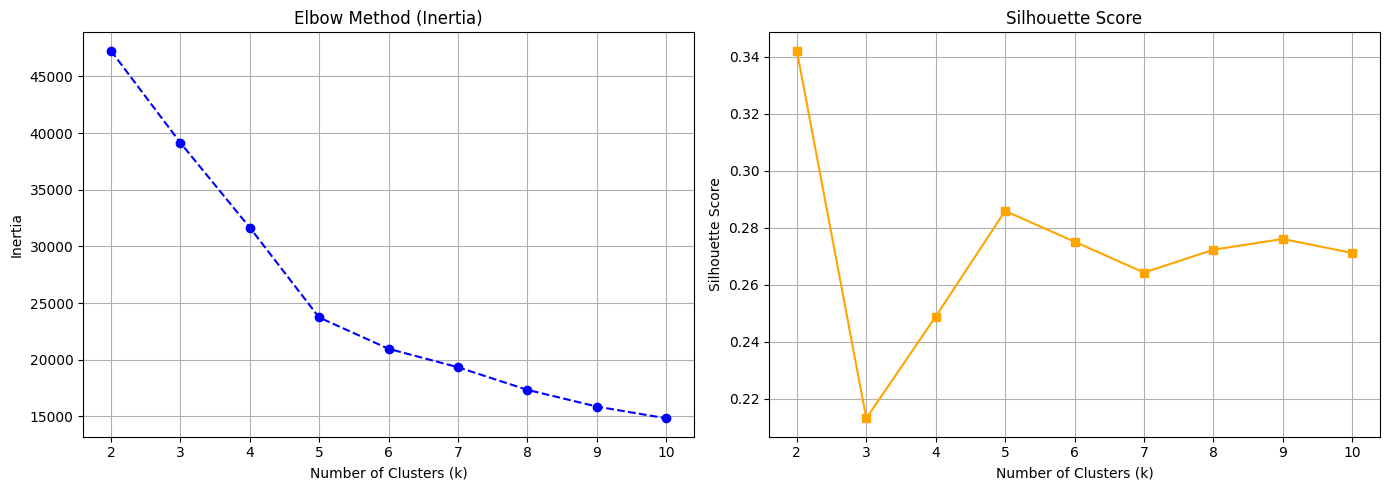

In [ ]:
inertia_values = []
silhouette_scores = []

# It is standard practice to test k values between 2 and 10
# (Silhouette score requires at least 2 clusters to calculate)
k_range = range(2, 11) 

for k in k_range:
    print(f"Evaluating k={k}...")
    # 1. Initialize and fit the model for the current k
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    
    # 2. Append the Inertia for the Elbow Method
    inertia_values.append(kmeans.inertia_)
    
    # 3. Calculate and append the Silhouette Score
    # We pass the original scaled data and the cluster labels
    cluster_labels = kmeans.labels_
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

# --- Plotting the Results ---
# Create a figure with 1 row and 2 columns for side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Method
ax1.plot(k_range, inertia_values, marker='o', linestyle='--', color='blue')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(k_range)
ax1.grid(True)

# Plot 2: Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='orange')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range)
ax2.grid(True)

plt.tight_layout()
plt.show()

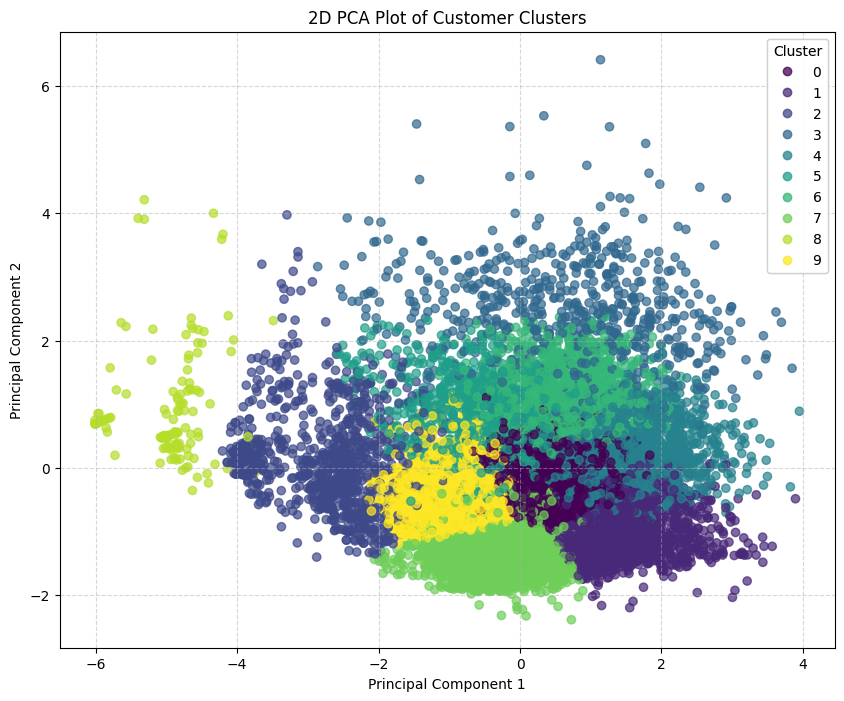

In [38]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Initialize PCA to reduce the data to 2 dimensions
pca = PCA(n_components=2)

# 2. Fit and transform your scaled multidimensional data
pca_features = pca.fit_transform(X_scaled)

# Extract the X and Y coordinates for easier plotting
pc1 = pca_features[:, 0]
pc2 = pca_features[:, 1]
cluster_labels = kmeans.labels_

# 3. Plot the results using pure Matplotlib
fig, ax = plt.subplots(figsize=(10, 8))

# Create the scatter plot
scatter = ax.scatter(
    pc1, 
    pc2, 
    c=cluster_labels,     # Color points by cluster label
    cmap='viridis',       # Apply the viridis color palette
    alpha=0.7             # Make points slightly transparent
)

# 4. Formatting and Labels
ax.set_title('2D PCA Plot of Customer Clusters')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.grid(True, linestyle='--', alpha=0.5)

# Extract legend elements directly from the scatter object
legend = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend)

plt.show()